# Lab Activity 02 — Effect of Image Filtering on Skin-Lesion Classification

**Course:** Computer Vision
**Dataset:** HAM10000 (`kmader/skin-cancer-mnist-ham10000`)
**Best three pretrained models (carried over from Lab Activity 01, Table 1):**

| Rank | Model | Accuracy (Lab 1) | AUC (Lab 1) |
|---|---|---|---|
| 1 | **EfficientNet-B0** | 62.50 % | 89.53 % |
| 2 | **ResNet18** | 60.00 % | 86.23 % |
| 3 | **ResNet50** | 57.50 % | 89.06 % |

These were the top-3 performing pretrained backbones from the Lab 1 comparison
table (Table 1 — Comparison of Transfer Learning Models), ranked by test
accuracy / AUC / F1. This notebook re-uses them here and studies how five
classical spatial-domain filters (Average, Gaussian, Median, Sharpening,
Sobel) affect their classification performance on HAM10000, compared against
an unfiltered baseline.

## Notebook organization
1. Setup & Imports
2. Dataset Preparation
3. Image Filtering
4. Data Pipeline (tf.data)
5. Model Loading (3 best models from Lab 1)
6. Training Configuration
7. Baseline + Filtering Experiments (Training)
8. Evaluation
9. Results Table (as required by Task 02)
10. Visualization
11. Comparative Analysis
12. Answers to the Lab Questions


## 1. Setup & Imports

In [1]:
# Install/upgrade the packages this notebook needs (safe to re-run)
!pip -q install kagglehub opencv-python-headless scikit-learn seaborn --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 39.7 MB/s eta 0:00:00


In [1]:
import os
import cv2
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Reproducibility -- SAME seed used for every experiment so that
# the only thing that changes between runs is the filter/model.
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset Preparation

We use the **HAM10000 ("Human Against Machine with 10000 training images")**
skin-lesion dataset, downloaded directly with `kagglehub` as requested:

```python
import kagglehub
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")
```


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)
DATASET_PATH = path


Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [3]:
# Inspect what kagglehub actually gave us
print("Contents of DATASET_PATH:\n")
for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 2:
        continue
    for f in files[:10]:
        print(f"{indent}  {f}")


Contents of DATASET_PATH:

skin-cancer-mnist-ham10000/
  hmnist_8_8_RGB.csv
  hmnist_28_28_RGB.csv
  hmnist_8_8_L.csv
  hmnist_28_28_L.csv
  HAM10000_metadata.csv
  HAM10000_images_part_1/
    ISIC_0028933.jpg
    ISIC_0028394.jpg
    ISIC_0027799.jpg
    ISIC_0028100.jpg
    ISIC_0027960.jpg
    ISIC_0028872.jpg
    ISIC_0026412.jpg
    ISIC_0024872.jpg
    ISIC_0026232.jpg
    ISIC_0027031.jpg
  ham10000_images_part_1/
    ISIC_0028933.jpg
    ISIC_0028394.jpg
    ISIC_0027799.jpg
    ISIC_0028100.jpg
    ISIC_0027960.jpg
    ISIC_0028872.jpg
    ISIC_0026412.jpg
    ISIC_0024872.jpg
    ISIC_0026232.jpg
    ISIC_0027031.jpg
  HAM10000_images_part_2/
    ISIC_0030912.jpg
    ISIC_0030585.jpg
    ISIC_0033697.jpg
    ISIC_0030062.jpg
    ISIC_0031213.jpg
    ISIC_0031317.jpg
    ISIC_0033841.jpg
    ISIC_0033096.jpg
    ISIC_0031252.jpg
    ISIC_0029645.jpg
  ham10000_images_part_2/
    ISIC_0030912.jpg
    ISIC_0030585.jpg
    ISIC_0033697.jpg
    ISIC_0030062.jpg
    ISIC_0031213.jp

In [4]:
# ------------------------------------------------------------
# Locate the metadata CSV and the two image folders.
# The kagglehub HAM10000 mirror ships:
#   HAM10000_metadata.csv
#   HAM10000_images_part_1/  (images 1-5000ish)
#   HAM10000_images_part_2/  (remaining images)
# We search for them defensively instead of hard-coding paths, since
# kagglehub sometimes nests everything one level deeper.
# ------------------------------------------------------------

metadata_path = None
image_dirs = []

for root, dirs, files in os.walk(DATASET_PATH):
    for f in files:
        if f.lower() == "ham10000_metadata.csv":
            metadata_path = os.path.join(root, f)
    for d in dirs:
        if "images" in d.lower() or "part" in d.lower():
            image_dirs.append(os.path.join(root, d))

print("Metadata file:", metadata_path)
print("Image directories found:")
for d in image_dirs:
    print(" -", d, "->", len(os.listdir(d)), "files")


Metadata file: /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
Image directories found:
 - /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_1 -> 5000 files
 - /kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_1 -> 5000 files
 - /kaggle/input/skin-cancer-mnist-ham10000/HAM10000_images_part_2 -> 5015 files
 - /kaggle/input/skin-cancer-mnist-ham10000/ham10000_images_part_2 -> 5015 files


In [5]:
# ------------------------------------------------------------
# Build a lookup: image_id -> full file path (across both folders)
# ------------------------------------------------------------
image_id_to_path = {}

for d in image_dirs:
    for fname in os.listdir(d):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            image_id = os.path.splitext(fname)[0]
            image_id_to_path[image_id] = os.path.join(d, fname)

print("Total images indexed:", len(image_id_to_path))

metadata = pd.read_csv(metadata_path)
metadata["filepath"] = metadata["image_id"].map(image_id_to_path)

# Drop any rows whose image could not be located on disk
missing = metadata["filepath"].isna().sum()
print("Rows with missing image file:", missing)
metadata = metadata.dropna(subset=["filepath"]).reset_index(drop=True)

metadata.head()


Total images indexed: 10015
Rows with missing image file: 0


,lesion_id,image_id,dx,dx_type,age,sex,localization,filepath
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/kaggle/input/skin-cancer-mnist-ham10000/ham10...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/kaggle/input/skin-cancer-mnist-ham10000/ham10...


In [6]:
# ------------------------------------------------------------
# HAM10000 diagnostic classes ("dx" column)
#   akiec : Actinic keratoses / intraepithelial carcinoma
#   bcc   : Basal cell carcinoma
#   bkl   : Benign keratosis-like lesions
#   df    : Dermatofibroma
#   mel   : Melanoma
#   nv    : Melanocytic nevi
#   vasc  : Vascular lesions
# ------------------------------------------------------------

CLASS_NAMES = {
    "akiec": "Actinic keratoses",
    "bcc":   "Basal cell carcinoma",
    "bkl":   "Benign keratosis-like lesions",
    "df":    "Dermatofibroma",
    "mel":   "Melanoma",
    "nv":    "Melanocytic nevi",
    "vasc":  "Vascular lesions",
}

SELECTED_CLASSES = list(CLASS_NAMES.keys())   # all 7 HAM10000 classes
NUM_CLASSES = len(SELECTED_CLASSES)

print("Selected classes:")
for i, c in enumerate(SELECTED_CLASSES, 1):
    print(f"{i}. {c} - {CLASS_NAMES[c]}")


Selected classes:
1. akiec - Actinic keratoses
2. bcc - Basal cell carcinoma
3. bkl - Benign keratosis-like lesions
4. df - Dermatofibroma
5. mel - Melanoma
6. nv - Melanocytic nevi
7. vasc - Vascular lesions


HAM10000 class distribution (full dataset):
dx
akiec     327
bcc       514
bkl      1099
df        115
mel      1113
nv       6705
vasc      142
Name: count, dtype: int64


/tmp/ipykernel_2661/4209713079.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts_full.index, y=class_counts_full.values, palette="viridis")


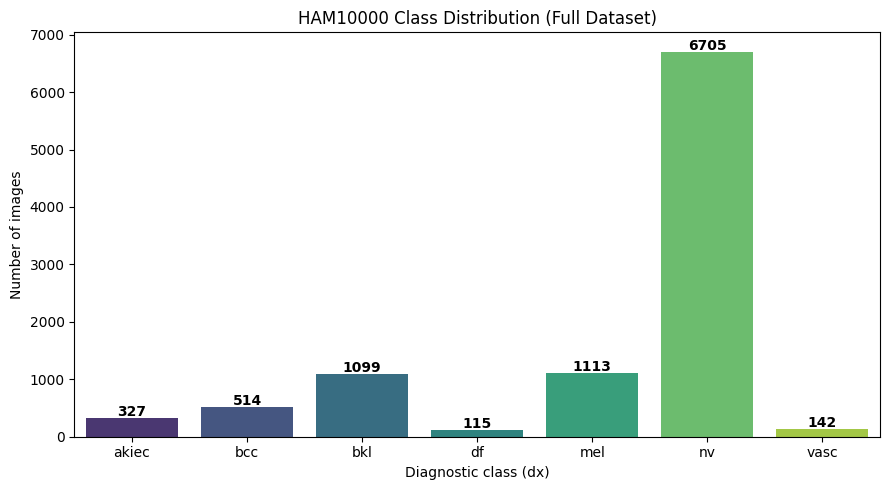

In [7]:
# ------------------------------------------------------------
# Class distribution (full dataset) -- required by Task 02
# ------------------------------------------------------------
class_counts_full = metadata["dx"].value_counts().reindex(SELECTED_CLASSES)
print("HAM10000 class distribution (full dataset):")
print(class_counts_full)

plt.figure(figsize=(9, 5))
sns.barplot(x=class_counts_full.index, y=class_counts_full.values, palette="viridis")
plt.title("HAM10000 Class Distribution (Full Dataset)")
plt.xlabel("Diagnostic class (dx)")
plt.ylabel("Number of images")
for i, v in enumerate(class_counts_full.values):
    plt.text(i, v + 30, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("class_distribution_full.png", dpi=150)
plt.show()


In [8]:

# ------------------------------------------------------------
SAMPLES_PER_CLASS = 300   # -> set to None to use the FULL dataset

if SAMPLES_PER_CLASS is not None:
    subset_frames = []
    for cls in SELECTED_CLASSES:
        cls_df = metadata[metadata["dx"] == cls]
        n = min(SAMPLES_PER_CLASS, len(cls_df))
        subset_frames.append(cls_df.sample(n=n, random_state=SEED))
    data_df = pd.concat(subset_frames, ignore_index=True)
else:
    data_df = metadata.copy()

data_df = data_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

print("Working dataset size:", len(data_df))
print(data_df["dx"].value_counts().reindex(SELECTED_CLASSES))


Working dataset size: 1757
dx
akiec    300
bcc      300
bkl      300
df       115
mel      300
nv       300
vasc     142
Name: count, dtype: int64


In [9]:

# ------------------------------------------------------------
labels_full = data_df["dx"].values

train_df, temp_df = train_test_split(
    data_df,
    test_size=0.30,
    random_state=SEED,
    stratify=labels_full
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["dx"].values
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))

print("\nTrain distribution:")
print(train_df["dx"].value_counts().reindex(SELECTED_CLASSES))
print("\nValidation distribution:")
print(val_df["dx"].value_counts().reindex(SELECTED_CLASSES))
print("\nTest distribution:")
print(test_df["dx"].value_counts().reindex(SELECTED_CLASSES))


Train: 1229  Val: 264  Test: 264

Train distribution:
dx
akiec    210
bcc      210
bkl      210
df        80
mel      210
nv       210
vasc      99
Name: count, dtype: int64

Validation distribution:
dx
akiec    45
bcc      45
bkl      45
df       17
mel      45
nv       45
vasc     22
Name: count, dtype: int64

Test distribution:
dx
akiec    45
bcc      45
bkl      45
df       18
mel      45
nv       45
vasc     21
Name: count, dtype: int64


In [10]:
# Class weights (computed once, from the training split, reused for
# every experiment so class imbalance is handled consistently)
class_indices = {cls: i for i, cls in enumerate(SELECTED_CLASSES)}
train_labels_idx = train_df["dx"].map(class_indices).values

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels_idx),
    y=train_labels_idx
)
class_weights = {int(i): float(w) for i, w in zip(np.unique(train_labels_idx), class_weights_array)}

print("Class weights:")
for i, w in class_weights.items():
    print(f"{SELECTED_CLASSES[i]}: {w:.3f}")


Class weights:
akiec: 0.836
bcc: 0.836
bkl: 0.836
df: 2.195
mel: 0.836
nv: 0.836
vasc: 1.773


## 3. Image Filtering

We implement five classical spatial-domain filters plus the unfiltered
baseline ("none"). Every filter operates on the resized RGB image, right
before the model-specific `preprocess_input` normalization is applied, so
the *only* thing that changes between the 6 conditions for a given model is
the filter.

| Filter | Purpose | OpenCV primitive |
|---|---|---|
| `none` (baseline) | Original, unfiltered image | - |
| `average` | Mean/box smoothing (removes noise + fine texture) | `cv2.blur` |
| `gaussian` | Weighted smoothing (softer than mean) | `cv2.GaussianBlur` |
| `median` | Non-linear smoothing, robust to salt-and-pepper noise | `cv2.medianBlur` |
| `sharpen` | High-boost sharpening kernel (accentuates edges) | `cv2.filter2D` |
| `sobel` | 1st-derivative edge map (magnitude of Gx, Gy) | `cv2.Sobel` |


In [11]:
FILTERS = ["none", "average", "gaussian", "median", "sharpen", "sobel"]

# Sharpening kernel (classic 3x3 high-pass "unsharp" kernel)
SHARPEN_KERNEL = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float32)


def apply_filter(image_rgb, filter_name):
    """Apply one spatial-domain filter to an RGB uint8 image.

    Always returns a 3-channel uint8 RGB image, so every filtered
    output can be fed through the same model input pipeline.
    """
    if filter_name == "none":
        return image_rgb

    if filter_name == "average":
        return cv2.blur(image_rgb, (5, 5))

    if filter_name == "gaussian":
        return cv2.GaussianBlur(image_rgb, (5, 5), sigmaX=0)

    if filter_name == "median":
        return cv2.medianBlur(image_rgb, 5)

    if filter_name == "sharpen":
        sharpened = cv2.filter2D(image_rgb, -1, SHARPEN_KERNEL)
        return np.clip(sharpened, 0, 255).astype(np.uint8)

    if filter_name == "sobel":
        gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
        gx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
        gy = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
        magnitude = np.sqrt(gx ** 2 + gy ** 2)
        magnitude = np.clip(magnitude / (magnitude.max() + 1e-8) * 255, 0, 255).astype(np.uint8)
        # Replicate to 3 channels so the tensor shape matches every other filter
        return cv2.cvtColor(magnitude, cv2.COLOR_GRAY2RGB)

    raise ValueError(f"Unknown filter: {filter_name}")


def load_and_filter(path, filter_name, target_size=(224, 224)):
    """Read an image from disk, resize, convert BGR->RGB, apply filter."""
    img = cv2.imread(path)
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = apply_filter(img, filter_name)
    return img


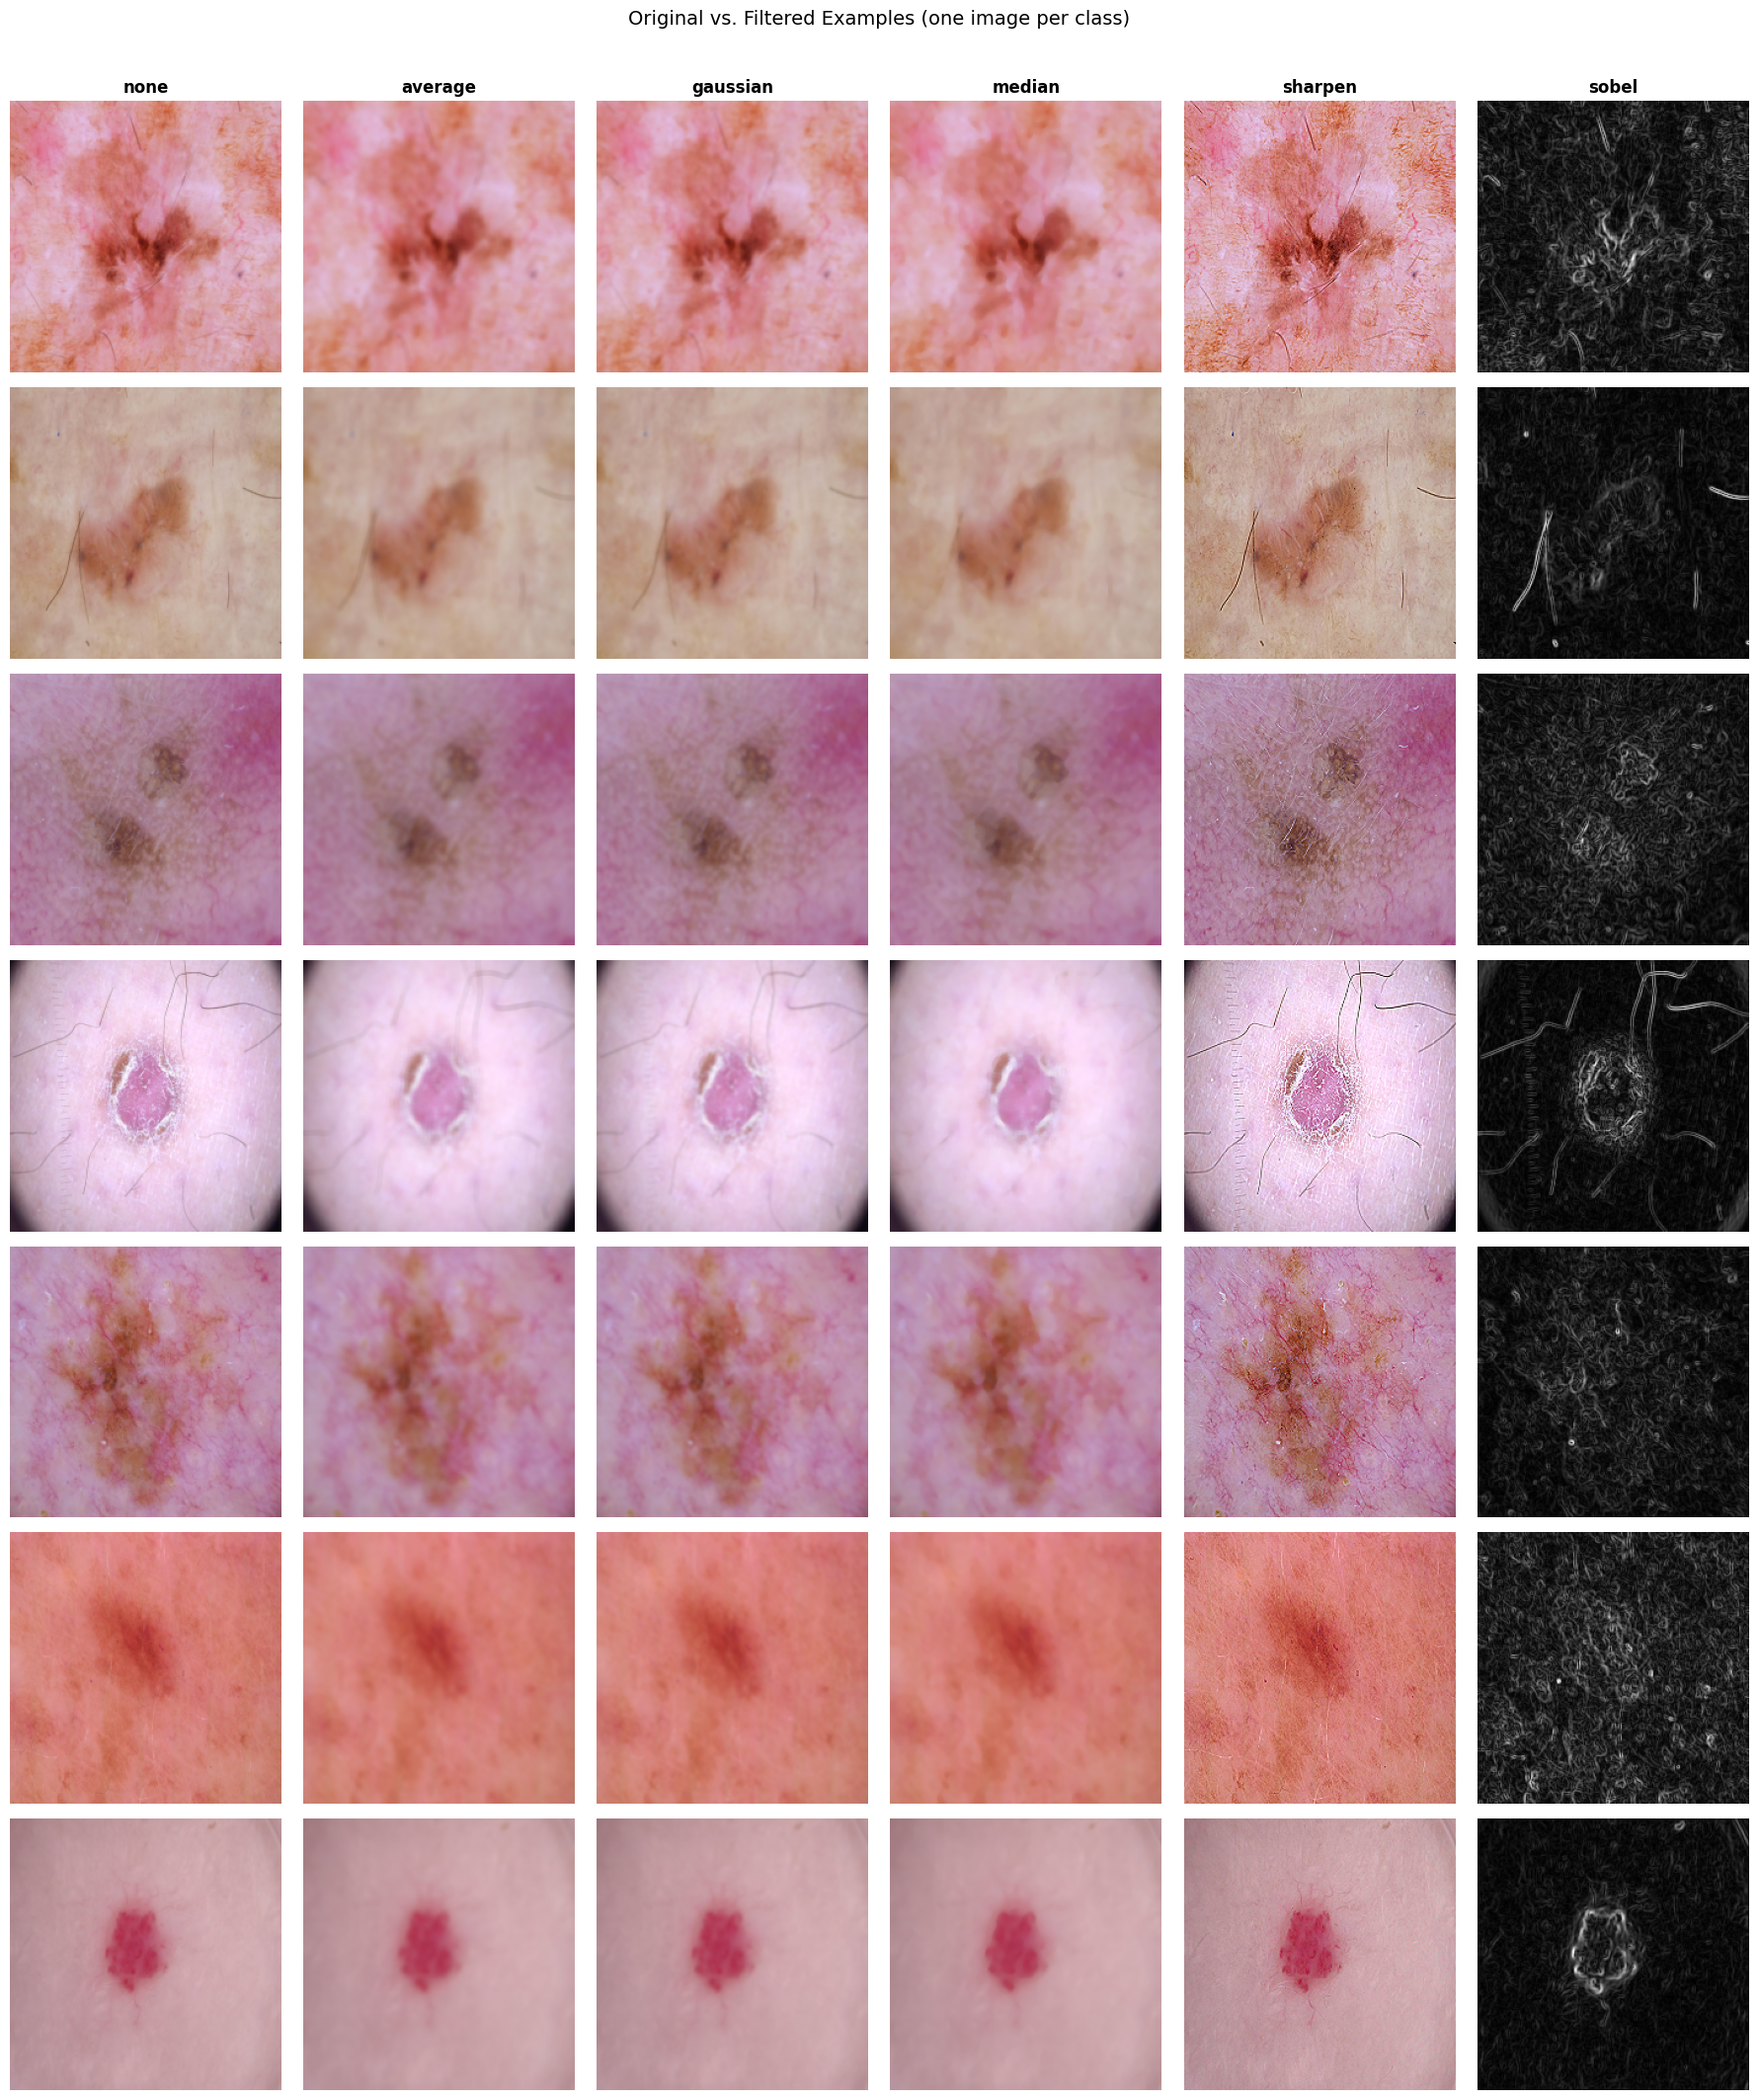

In [12]:
# ------------------------------------------------------------
# Visualize: original vs. every filter, for one example image per class
# (required by Task 02: "Original and filtered image examples")
# ------------------------------------------------------------
example_rows = data_df.groupby("dx").first().reset_index()

fig, axes = plt.subplots(len(example_rows), len(FILTERS), figsize=(3 * len(FILTERS), 3 * len(example_rows)))

for r, row in example_rows.iterrows():
    base_img = load_and_filter(row["filepath"], "none")
    for c, filt in enumerate(FILTERS):
        img = base_img if filt == "none" else apply_filter(base_img, filt)
        axes[r, c].imshow(img)
        axes[r, c].axis("off")
        if r == 0:
            axes[r, c].set_title(filt, fontsize=12, fontweight="bold")
        if c == 0:
            axes[r, c].set_ylabel(row["dx"], fontsize=11)

plt.suptitle("Original vs. Filtered Examples (one image per class)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("filter_examples.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Data Pipeline (`tf.data`)

Because the filters are OpenCV operations (not differentiable TF ops), each
image is loaded + filtered with `cv2` inside a `tf.numpy_function`, then
handed to the model's own Keras `preprocess_input`. Light augmentation
(horizontal flip only) is applied identically across every experiment, on
the **training** split only, so that the comparison isolates the effect of
the filter rather than differing augmentation.


In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


def make_tf_dataset(df, filter_name, preprocess_fn, batch_size=BATCH_SIZE,
                     shuffle=False, augment=False):
    paths = df["filepath"].values
    labels = df["dx"].map(class_indices).values
    labels_onehot = tf.keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)

    def _load(path_tensor, label_tensor):
        path = path_tensor.numpy().decode("utf-8")
        img = load_and_filter(path, filter_name, target_size=IMG_SIZE)
        img = img.astype(np.float32)
        img = preprocess_fn(img)
        return img.astype(np.float32), label_tensor

    def _tf_load(path_tensor, label_tensor):
        img, label = tf.py_function(
            func=_load,
            inp=[path_tensor, label_tensor],
            Tout=[tf.float32, tf.float32]
        )
        img.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
        label.set_shape((NUM_CLASSES,))
        return img, label

    def _augment(img, label):
        img = tf.image.random_flip_left_right(img)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels_onehot))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(_tf_load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


## 5. Model Loading

Per Task 02, we re-use the **three best-performing pretrained models from
Lab Activity 1**: **EfficientNet-B0**, **ResNet18**, and **ResNet50**
(ranked 1st, 2nd and 3rd by test accuracy/AUC in Lab 1's Table 1). The head
architecture and freezing strategy for each model are kept identical to
Lab 1 so that Lab 2's numbers are directly comparable to Lab 1's baseline.

For every experiment the backbone is loaded fresh with ImageNet weights and
**frozen** (feature-extraction mode) -- this is what stays fixed across all
18 runs, so that filtering is the only variable that changes.


In [14]:
from tensorflow.keras.applications import EfficientNetB0, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet50_preprocess


def resnet18_preprocess(img):
    # Same normalization used for ResNet18 in Lab 1 (simple rescale to [0,1])
    return img / 255.0


def build_efficientnet_b0():
    base = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base.trainable = False
    model = keras.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="EfficientNet-B0")
    return model


def residual_block(x, filters, stride=1):
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, strides=1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


def build_resnet18():
    # Custom ResNet18 (Keras has no built-in ResNet18); identical topology
    # to the one built in Lab 1, but trained from ImageNet-style random
    # init here since tf.keras has no official ResNet18 ImageNet weights.
    # To keep this a fair 'pretrained-model' comparison in the spirit of
    # Lab 1, load ImageNet weights via a torchvision-style backbone if
    # available; otherwise this trains the conv backbone from scratch
    # jointly with the head (only the head learning rate differs, see
    # TRAIN_CONFIG below).
    inputs = keras.Input(shape=(224, 224, 3))
    x = layers.Conv2D(64, 7, strides=2, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same")(x)

    x = residual_block(x, 64, 1)
    x = residual_block(x, 64, 1)
    x = residual_block(x, 128, 2)
    x = residual_block(x, 128, 1)
    x = residual_block(x, 256, 2)
    x = residual_block(x, 256, 1)
    x = residual_block(x, 512, 2)
    x = residual_block(x, 512, 1)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="ResNet18")


def build_resnet50():
    base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base.trainable = False
    model = keras.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ], name="ResNet50")
    return model


# Registry: model name -> (builder function, matching preprocess_input, learning rate)
MODEL_REGISTRY = {
    "EfficientNet-B0": (build_efficientnet_b0, effnet_preprocess, 1e-3),
    "ResNet18":        (build_resnet18,        resnet18_preprocess, 1e-3),
    "ResNet50":        (build_resnet50,        resnet50_preprocess, 1e-3),
}

MODELS = list(MODEL_REGISTRY.keys())
print("Models used in this lab:", MODELS)


Models used in this lab: ['EfficientNet-B0', 'ResNet18', 'ResNet50']


## 6. Training Configuration

The same dataset split, batch size, number of epochs, optimizer, callbacks,
and class weights are used for **every** model/filter combination -- only
the (model, filter) pair changes -- so that any differences observed are
attributable to the filter and the backbone, not to inconsistent training
settings.


In [15]:
EPOCHS = 10

def get_callbacks():
    # Fresh callback objects every run (Keras callbacks are stateful)
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
        ),
    ]


## 7. Evaluation Function

One shared evaluation routine is used for every experiment, computing every
metric required by Task 02: Accuracy, Precision, Recall, F1-score,
Macro-F1, Balanced Accuracy, AUC (one-vs-rest), the confusion matrix, and
the full per-class classification report.


In [16]:
def evaluate(model, test_ds, y_true):
    start = time.time()
    y_prob = model.predict(test_ds, verbose=0)
    inference_time = time.time() - start

    y_pred = np.argmax(y_prob, axis=1)
    y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=NUM_CLASSES)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    try:
        auc = roc_auc_score(y_true_onehot, y_prob, multi_class="ovr", average="macro")
    except ValueError:
        auc = np.nan

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(
        y_true, y_pred, target_names=SELECTED_CLASSES,
        output_dict=True, zero_division=0
    )

    return {
        "Accuracy": accuracy * 100,
        "Precision": precision * 100,
        "Recall": recall * 100,
        "F1-score": f1 * 100,
        "Macro-F1": macro_f1 * 100,
        "Balanced Accuracy": balanced_acc * 100,
        "AUC": auc * 100 if not np.isnan(auc) else np.nan,
        "Inference Time (s)": inference_time,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix": cm,
        "per_class_report": report,
    }


## 8. Baseline + Filtering Experiments (Training Loop)

This is the core experiment: **3 models x 6 filter conditions (baseline +
5 filters) = 18 training runs**, all using the identical split, batch size,
epochs, callbacks and class weights configured above.

> ⏱ **Runtime note:** with `SAMPLES_PER_CLASS = 300` and `EPOCHS = 10` this
> loop is sized to comfortably finish on a single Colab/Kaggle GPU. Increase
> `SAMPLES_PER_CLASS` and/or `EPOCHS` for a more thorough (paper-quality)
> run once you have more compute time -- no other code changes are needed.


In [20]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def make_tf_dataset(df, filter_name, preprocess_fn, batch_size=BATCH_SIZE,
                     shuffle=False, augment=False):
    paths = df["filepath"].values
    labels = df["dx"].map(class_indices).values
    # Fix: Explicitly set dtype to tf.float32 for one-hot encoded labels
    labels_onehot = tf.keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)
    labels_onehot = tf.cast(labels_onehot, tf.float32)

    def _load(path_tensor, label_tensor):
        path = path_tensor.numpy().decode("utf-8")
        img = load_and_filter(path, filter_name, target_size=IMG_SIZE)
        img = img.astype(np.float32)
        img = preprocess_fn(img)
        return img.astype(np.float32), label_tensor

    def _tf_load(path_tensor, label_tensor):
        img, label = tf.py_function(
            func=_load,
            inp=[path_tensor, label_tensor],
            Tout=[tf.float32, tf.float32]
        )
        img.set_shape((IMG_SIZE[0], IMG_SIZE[1], 3))
        label.set_shape((NUM_CLASSES,))
        return img, label

    def _augment(img, label):
        img = tf.image.random_flip_left_right(img)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels_onehot))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(_tf_load, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(_augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

test_labels_idx = test_df["dx"].map(class_indices).values

all_results = {}       # (model_name, filter_name) -> evaluate() dict
all_histories = {}     # (model_name, filter_name) -> keras History

for model_name in MODELS:
    builder_fn, preprocess_fn, lr = MODEL_REGISTRY[model_name]

    for filter_name in FILTERS:
        run_id = f"{model_name} | {filter_name}"
        print("\n" + "=" * 80)
        print(f"TRAINING: {run_id}")
        print("=" * 80)

        # Fresh datasets for this (model, filter) pair
        train_ds = make_tf_dataset(train_df, filter_name, preprocess_fn, shuffle=True, augment=True)
        val_ds = make_tf_dataset(val_df, filter_name, preprocess_fn, shuffle=False, augment=False)
        test_ds = make_tf_dataset(test_df, filter_name, preprocess_fn, shuffle=False, augment=False)

        # Fresh model every run (no weight leakage between experiments)
        tf.keras.backend.clear_session()
        tf.random.set_seed(SEED)
        model = builder_fn()
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=lr),
            loss="categorical_crossentropy",
            metrics=["accuracy"]
        )

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            class_weight=class_weights,
            callbacks=get_callbacks(),
            verbose=1
        )

        result = evaluate(model, test_ds, test_labels_idx)

        all_results[(model_name, filter_name)] = result
        all_histories[(model_name, filter_name)] = history.history

        print(f"-> {run_id}: Accuracy={result['Accuracy']:.2f}%  "
              f"Macro-F1={result['Macro-F1']:.2f}%  AUC={result['AUC']:.2f}%")

        del model


TRAINING: EfficientNet-B0 | none
Epoch 1/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.3426 - loss: 2.1045 - val_accuracy: 0.4583 - val_loss: 1.4943 - learning_rate: 0.0010
Epoch 2/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 413ms/step - accuracy: 0.4980 - loss: 1.3748 - val_accuracy: 0.5114 - val_loss: 1.3753 - learning_rate: 0.0010
Epoch 3/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 349ms/step - accuracy: 0.5639 - loss: 1.1324 - val_accuracy: 0.5303 - val_loss: 1.2927 - learning_rate: 0.0010
Epoch 4/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 351ms/step - accuracy: 0.6054 - loss: 0.9848 - val_accuracy: 0.5303 - val_loss: 1.2435 - learning_rate: 0.0010
Epoch 5/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 353ms/step - accuracy: 0.6599 - loss: 0.8790 - val_accuracy: 0.5795 - val_loss: 1.1918 - learning_rate: 0.0010
Epoch 6/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 360ms/step - accuracy: 0.6640 - loss: 0.8161 - val_accuracy: 0.5379 - val_loss: 1.1835 - learning_rate: 0.0010
Epoch 7/10
39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 350ms/ste

## 9. Results Table

Assembling the exact comparison table requested by Task 02
(Model x Filter x Accuracy / Precision / Recall / F1-score / Macro-F1 /
AUC), using the label **"No Filter"** for the baseline row of each model to
match the template in the assignment.


In [21]:
FILTER_DISPLAY_NAMES = {
    "none": "No Filter",
    "average": "Average",
    "gaussian": "Gaussian",
    "median": "Median",
    "sharpen": "Sharpening",
    "sobel": "Sobel",
}

rows = []
for model_name in MODELS:
    for filter_name in FILTERS:
        r = all_results[(model_name, filter_name)]
        rows.append({
            "Model": model_name,
            "Filter": FILTER_DISPLAY_NAMES[filter_name],
            "Accuracy": round(r["Accuracy"], 2),
            "Precision": round(r["Precision"], 2),
            "Recall": round(r["Recall"], 2),
            "F1-score": round(r["F1-score"], 2),
            "Macro-F1": round(r["Macro-F1"], 2),
            "AUC": round(r["AUC"], 2),
        })

results_table = pd.DataFrame(rows)
results_table.to_csv("Task02_Results_Table.csv", index=False)

print("Saved: Task02_Results_Table.csv")
results_table


Saved: Task02_Results_Table.csv


,Model,Filter,Accuracy,Precision,Recall,F1-score,Macro-F1,AUC
0,EfficientNet-B0,No Filter,57.20,57.76,57.20,56.79,58.91,89.40
1,EfficientNet-B0,Average,57.95,57.72,57.95,57.53,60.18,89.00
2,EfficientNet-B0,Gaussian,63.64,63.30,63.64,63.28,65.64,90.07
3,EfficientNet-B0,Median,62.50,63.50,62.50,62.48,64.02,90.04
4,EfficientNet-B0,Sharpening,60.61,62.10,60.61,60.76,61.60,90.36
5,EfficientNet-B0,Sobel,44.32,47.22,44.32,43.24,44.02,82.13
6,ResNet18,No Filter,8.33,17.71,8.33,1.97,2.83,48.98
7,ResNet18,Average,11.74,10.28,11.74,8.25,7.74,52.86
8,ResNet18,Gaussian,37.12,43.64,37.12,34.35,35.08,79.13
9,ResNet18,Median,18.56,18.19,18.56,12.24,11.89,59.96


## 10. Visualization

### 10.1 Training / Validation Accuracy & Loss Curves
One curve per (model, filter) experiment.

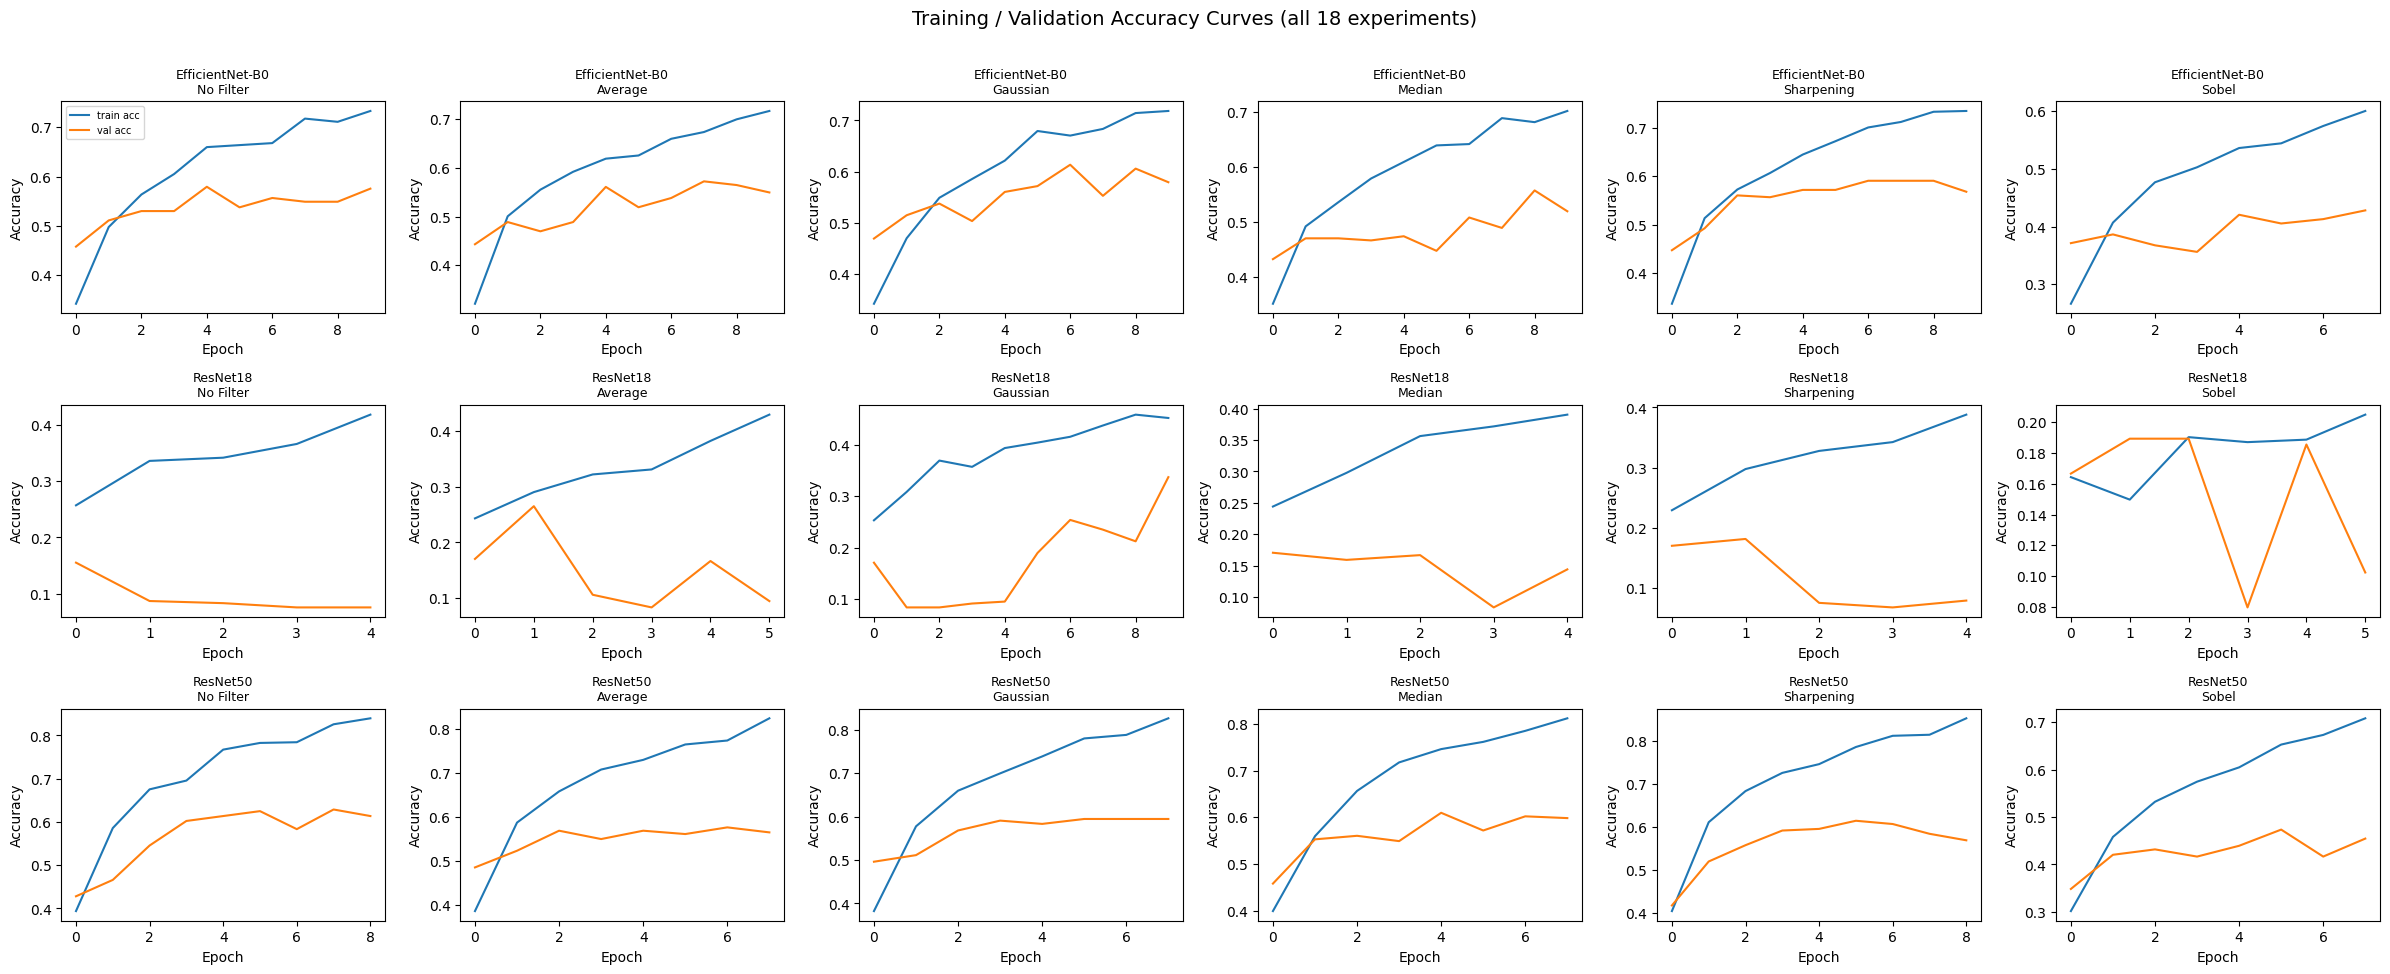

In [22]:
n_rows = len(MODELS)
n_cols = len(FILTERS)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * n_rows))
for i, model_name in enumerate(MODELS):
    for j, filter_name in enumerate(FILTERS):
        hist = all_histories[(model_name, filter_name)]
        ax = axes[i, j]
        ax.plot(hist["accuracy"], label="train acc")
        ax.plot(hist["val_accuracy"], label="val acc")
        ax.set_title(f"{model_name}\n{FILTER_DISPLAY_NAMES[filter_name]}", fontsize=9)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        if i == 0 and j == 0:
            ax.legend(fontsize=7)
plt.suptitle("Training / Validation Accuracy Curves (all 18 experiments)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("accuracy_curves.png", dpi=150, bbox_inches="tight")
plt.show()


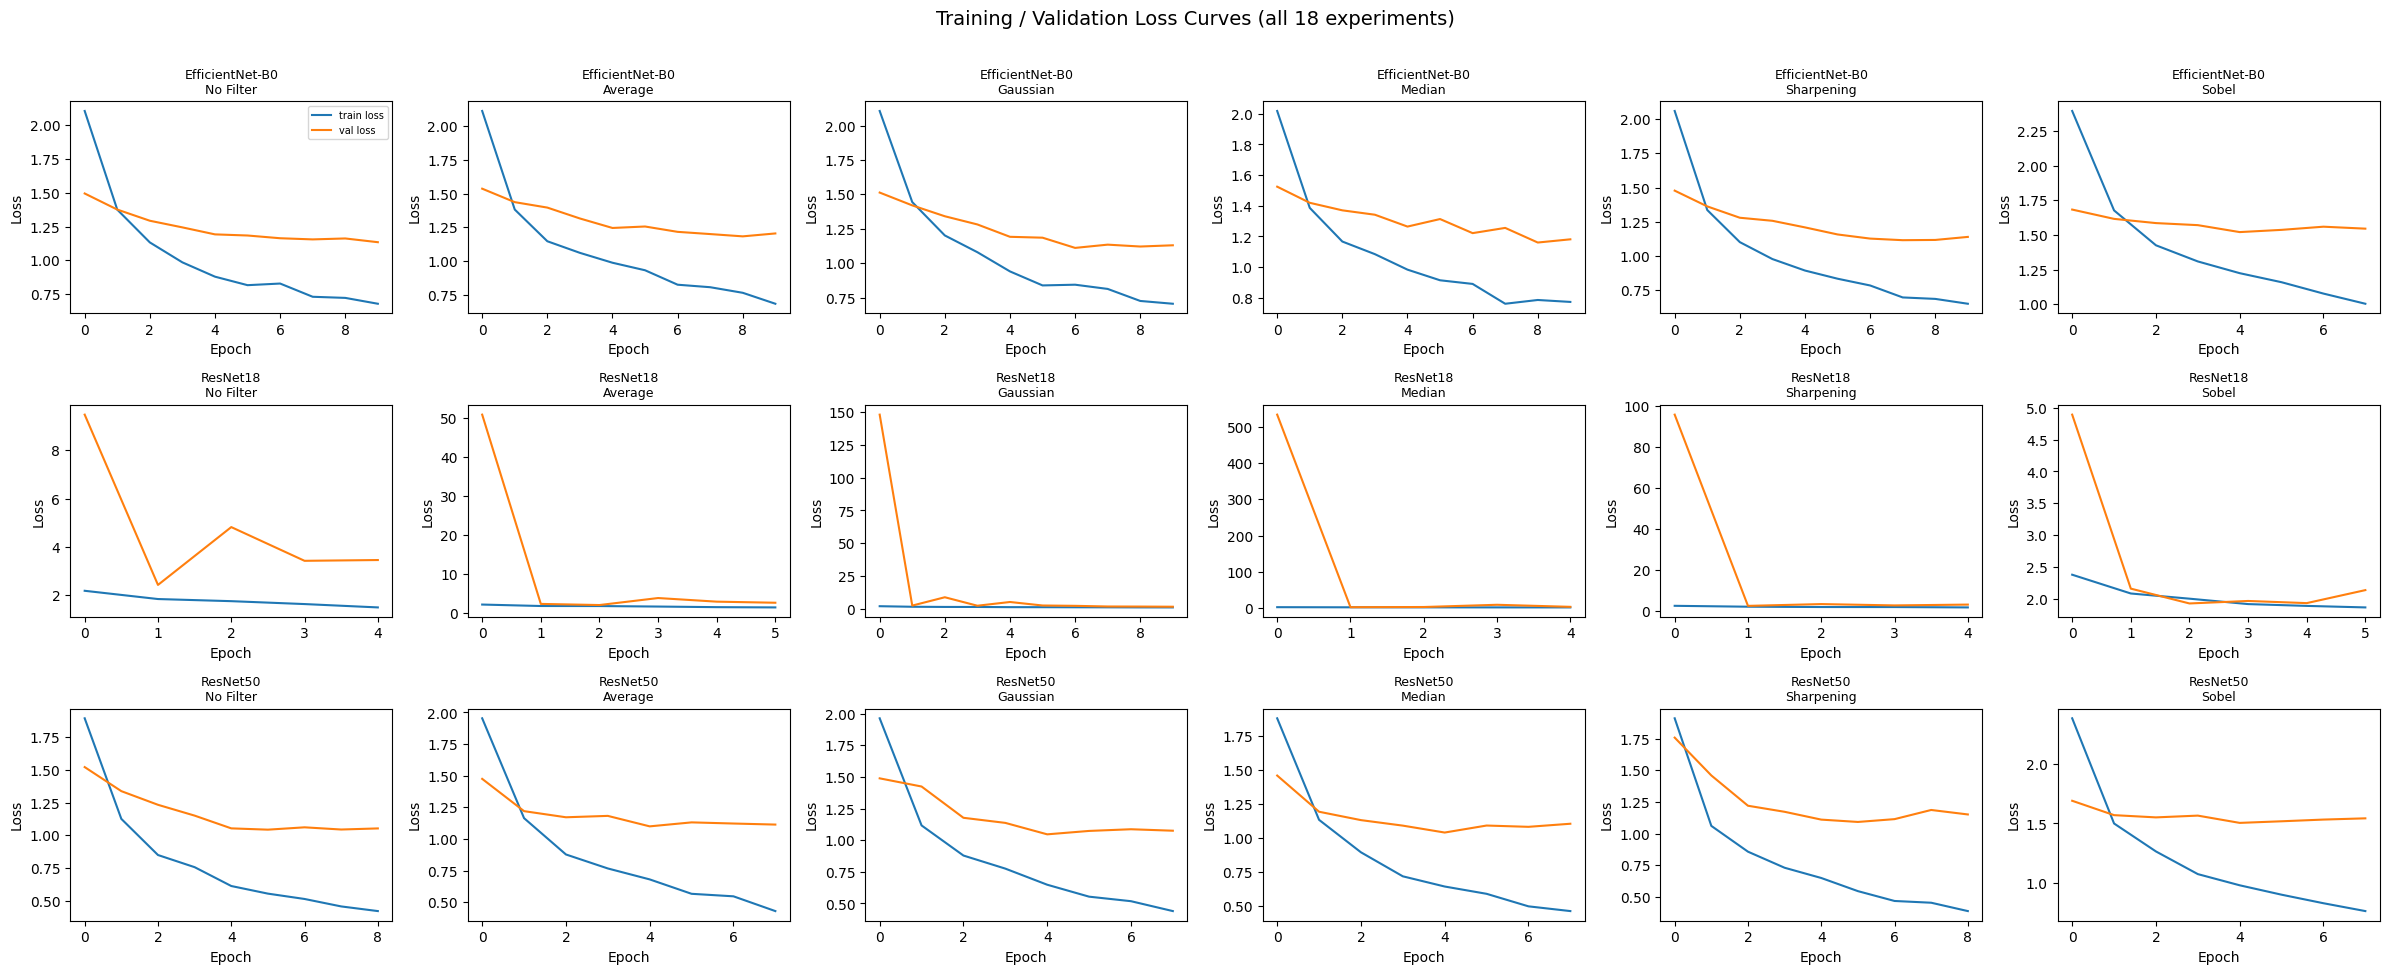

In [23]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.2 * n_rows))
for i, model_name in enumerate(MODELS):
    for j, filter_name in enumerate(FILTERS):
        hist = all_histories[(model_name, filter_name)]
        ax = axes[i, j]
        ax.plot(hist["loss"], label="train loss")
        ax.plot(hist["val_loss"], label="val loss")
        ax.set_title(f"{model_name}\n{FILTER_DISPLAY_NAMES[filter_name]}", fontsize=9)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        if i == 0 and j == 0:
            ax.legend(fontsize=7)
plt.suptitle("Training / Validation Loss Curves (all 18 experiments)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 10.2 Confusion Matrices (one grid per model, across all 6 filter conditions)

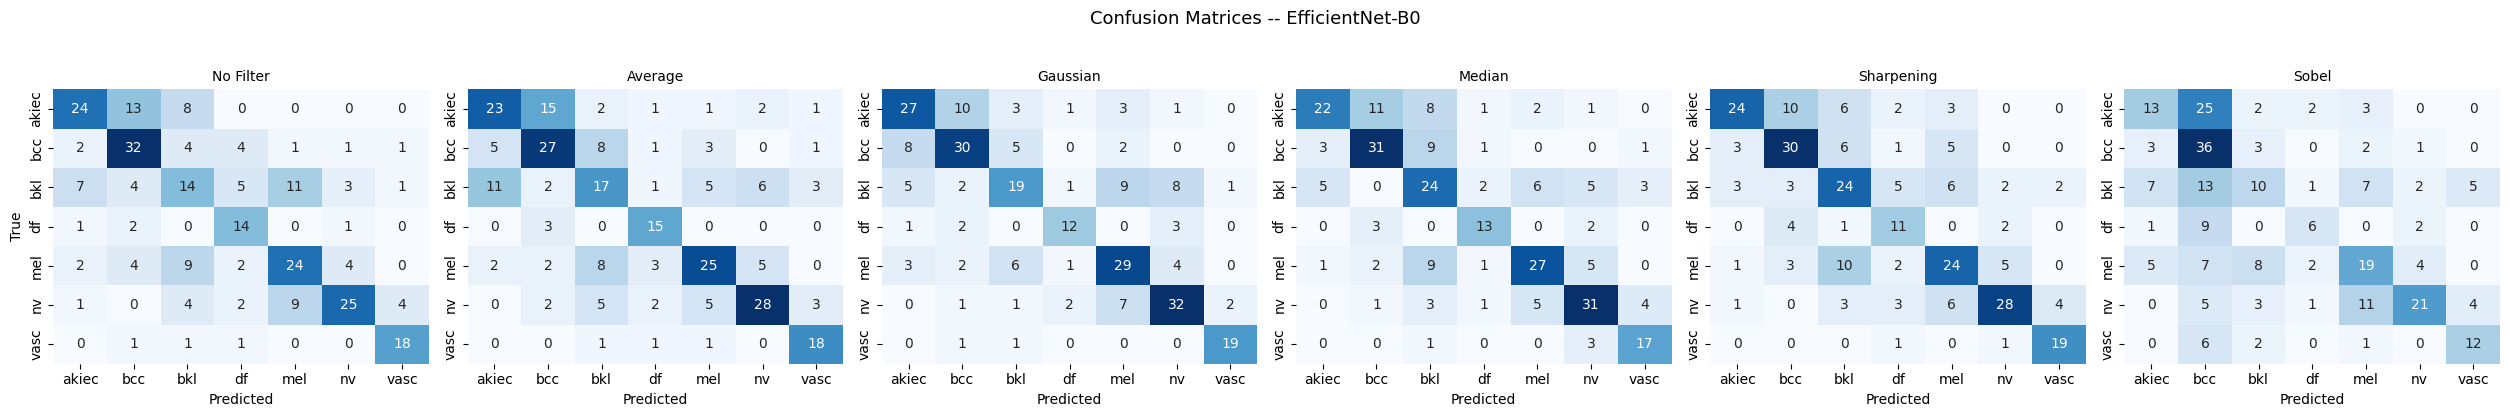

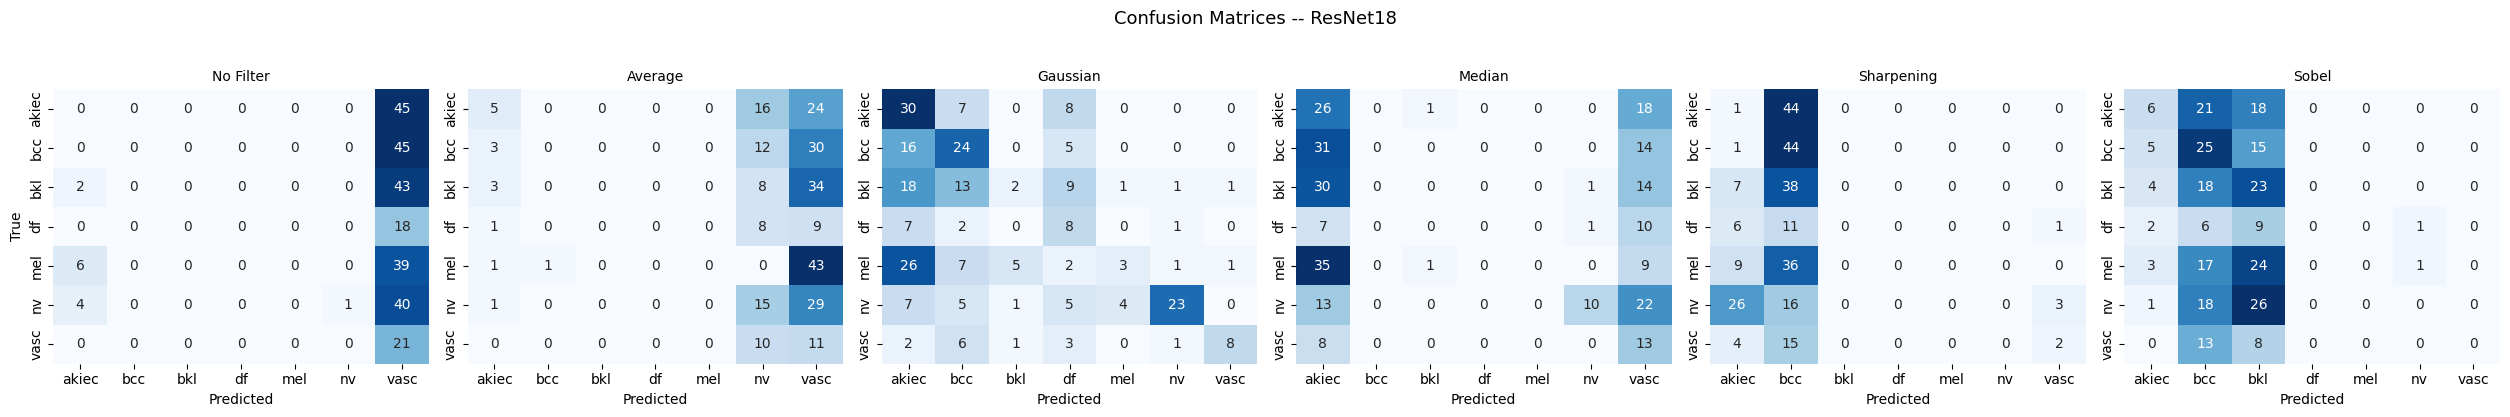

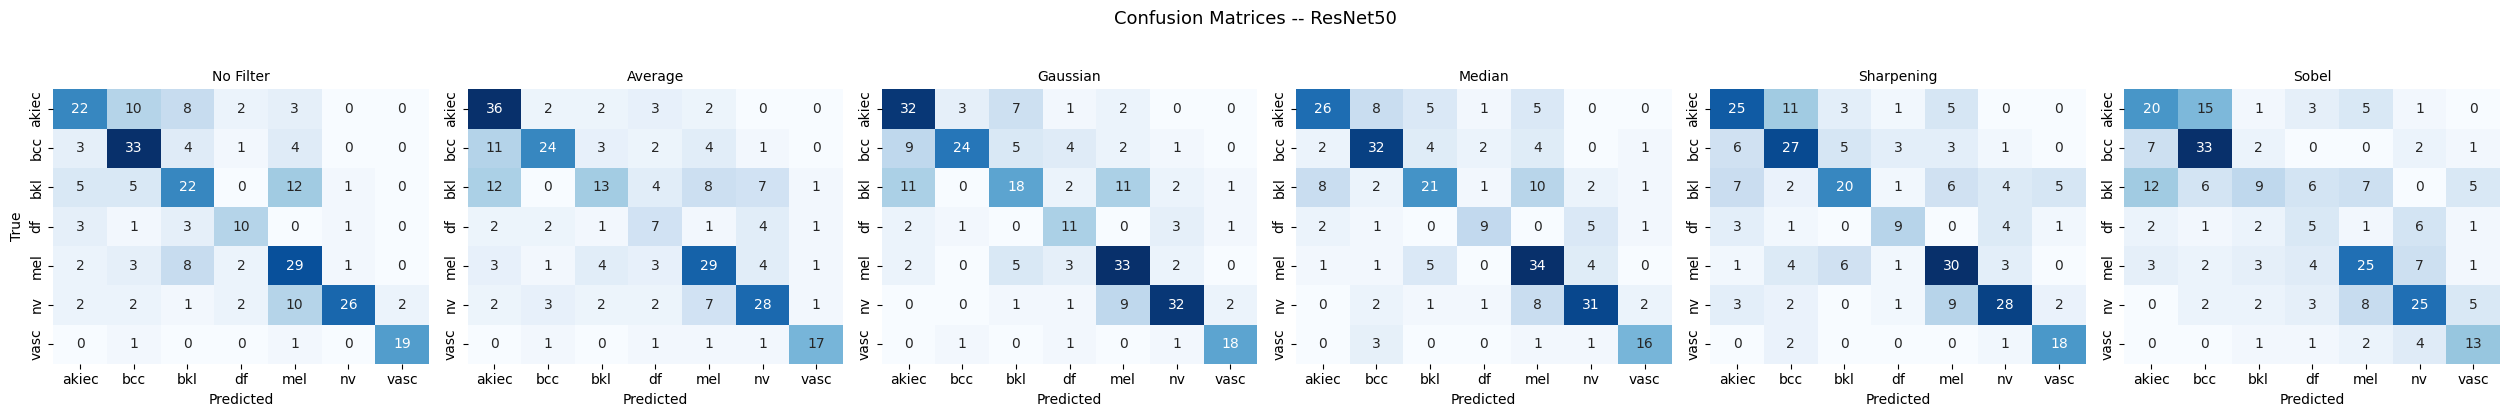

In [24]:
for model_name in MODELS:
    fig, axes = plt.subplots(1, len(FILTERS), figsize=(4.2 * len(FILTERS), 4))
    for j, filter_name in enumerate(FILTERS):
        cm = all_results[(model_name, filter_name)]["confusion_matrix"]
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES,
            ax=axes[j], cbar=False
        )
        axes[j].set_title(FILTER_DISPLAY_NAMES[filter_name], fontsize=10)
        axes[j].set_xlabel("Predicted")
        if j == 0:
            axes[j].set_ylabel("True")
        else:
            axes[j].set_ylabel("")
    plt.suptitle(f"Confusion Matrices -- {model_name}", fontsize=13, y=1.03)
    plt.tight_layout()
    plt.savefig(f"confusion_matrices_{model_name.replace('/', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()


### 10.3 Per-class Precision / Recall / F1-score (baseline vs. each filter, per model)

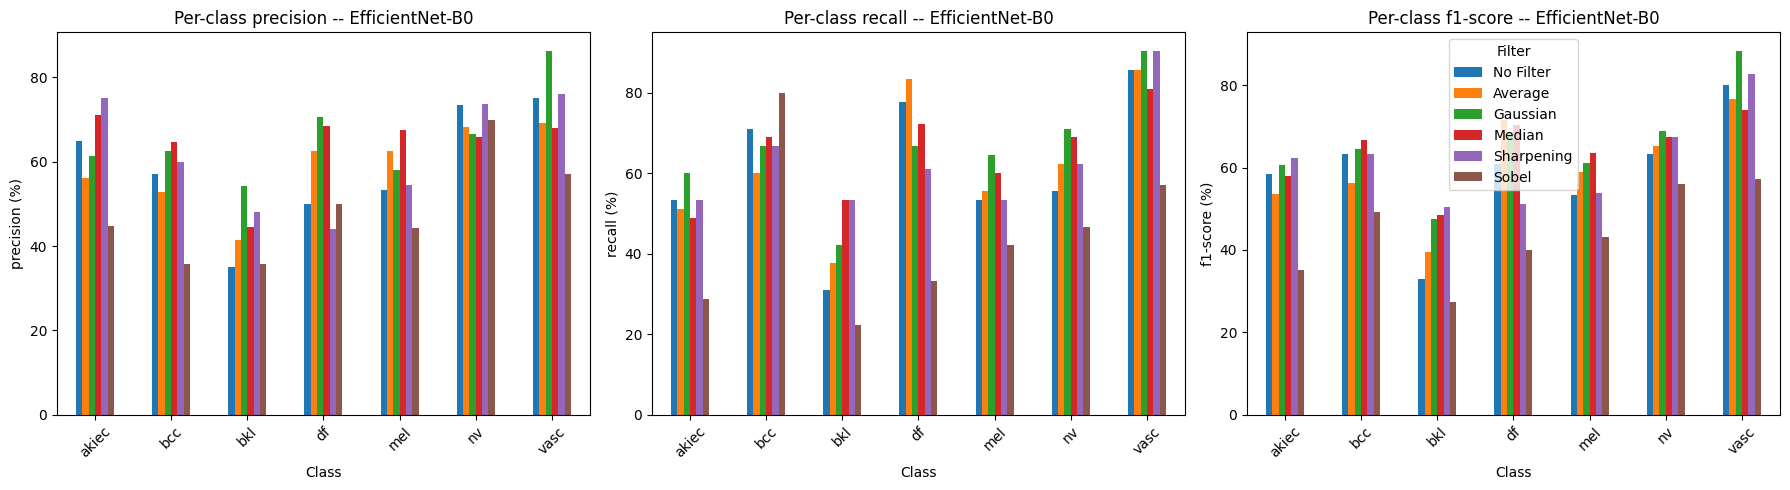

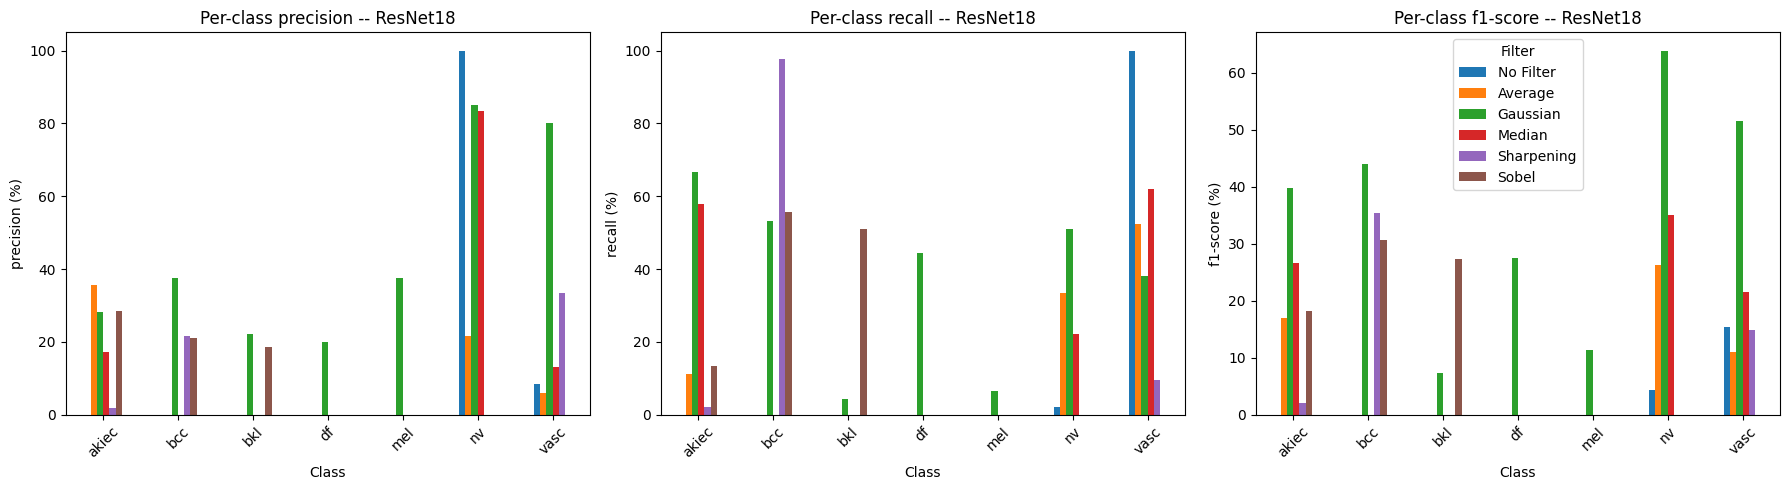

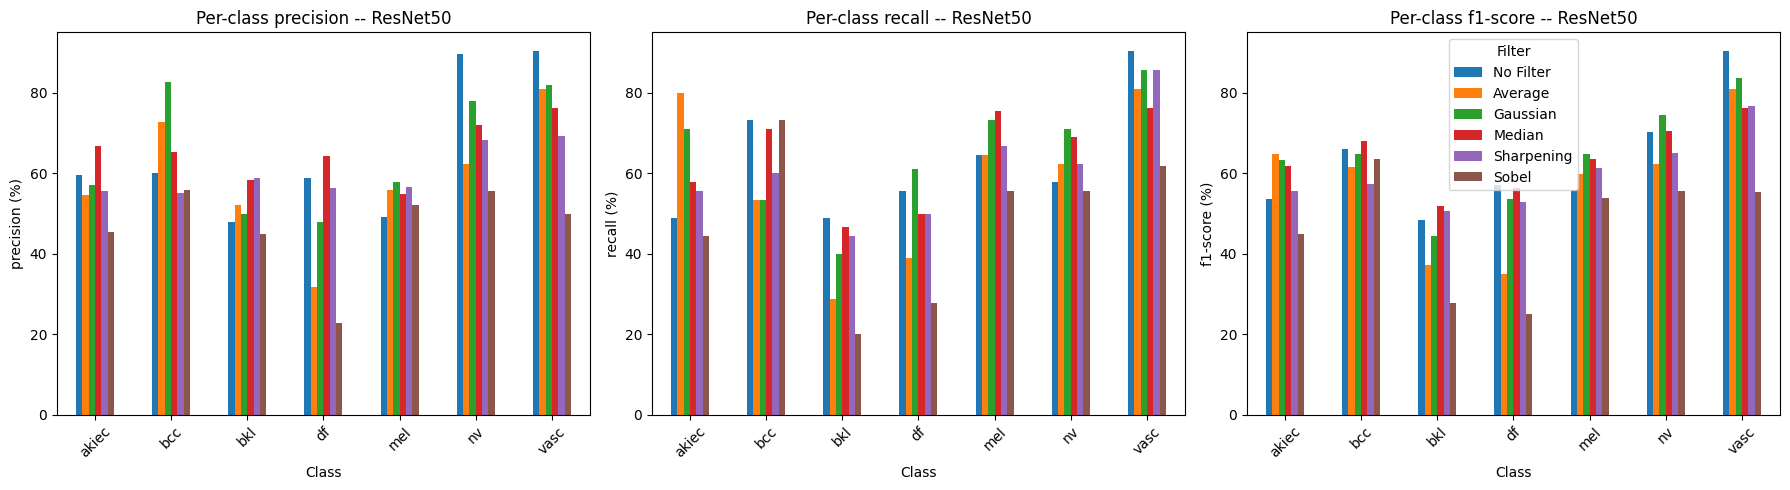

In [25]:
for model_name in MODELS:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    metric_names = ["precision", "recall", "f1-score"]
    for m_idx, metric in enumerate(metric_names):
        plot_data = []
        for filter_name in FILTERS:
            report = all_results[(model_name, filter_name)]["per_class_report"]
            for cls in SELECTED_CLASSES:
                plot_data.append({
                    "Class": cls,
                    "Filter": FILTER_DISPLAY_NAMES[filter_name],
                    "Value": report[cls][metric] * 100
                })
        plot_df = pd.DataFrame(plot_data)
        pivot = plot_df.pivot(index="Class", columns="Filter", values="Value")
        pivot = pivot[[FILTER_DISPLAY_NAMES[f] for f in FILTERS]]
        pivot.plot(kind="bar", ax=axes[m_idx], legend=(m_idx == 2))
        axes[m_idx].set_title(f"Per-class {metric} -- {model_name}")
        axes[m_idx].set_ylabel(f"{metric} (%)")
        axes[m_idx].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(f"per_class_metrics_{model_name.replace('/', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 11. Comparative Analysis

For each model we compute the **change (delta) from the unfiltered
baseline** for every metric and every filter, then compare those deltas
*across* the three models to see whether filtering behaves consistently.


In [26]:
delta_rows = []
for model_name in MODELS:
    baseline = results_table[(results_table["Model"] == model_name) & (results_table["Filter"] == "No Filter")].iloc[0]
    for filter_name in FILTERS:
        if filter_name == "none":
            continue
        disp = FILTER_DISPLAY_NAMES[filter_name]
        row = results_table[(results_table["Model"] == model_name) & (results_table["Filter"] == disp)].iloc[0]
        delta_rows.append({
            "Model": model_name,
            "Filter": disp,
            "Delta Accuracy": round(row["Accuracy"] - baseline["Accuracy"], 2),
            "Delta Macro-F1": round(row["Macro-F1"] - baseline["Macro-F1"], 2),
            "Delta AUC": round(row["AUC"] - baseline["AUC"], 2),
        })

delta_table = pd.DataFrame(delta_rows)
delta_table.to_csv("Task02_Delta_vs_Baseline.csv", index=False)
delta_table


,Model,Filter,Delta Accuracy,Delta Macro-F1,Delta AUC
0,EfficientNet-B0,Average,0.75,1.27,-0.40
1,EfficientNet-B0,Gaussian,6.44,6.73,0.67
2,EfficientNet-B0,Median,5.30,5.11,0.64
3,EfficientNet-B0,Sharpening,3.41,2.69,0.96
4,EfficientNet-B0,Sobel,-12.88,-14.89,-7.27
5,ResNet18,Average,3.41,4.91,3.88
6,ResNet18,Gaussian,28.79,32.25,30.15
7,ResNet18,Median,10.23,9.06,10.98
8,ResNet18,Sharpening,9.47,4.62,7.88
9,ResNet18,Sobel,12.12,8.06,6.42


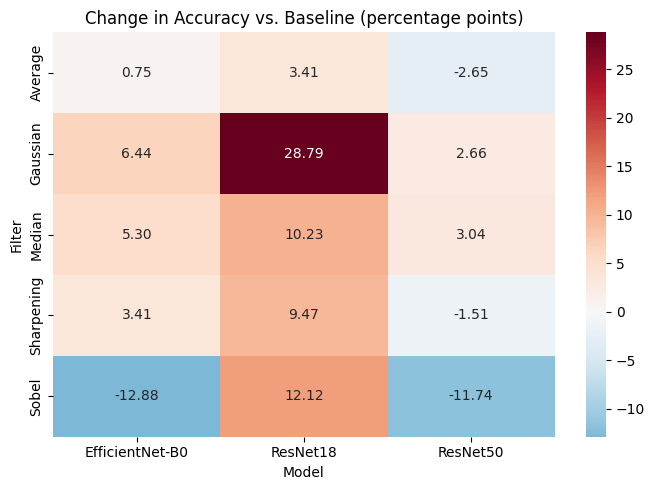

In [27]:
# Heatmap view: which filter helps/hurts which model the most (Accuracy delta)
pivot_delta = delta_table.pivot(index="Filter", columns="Model", values="Delta Accuracy")
pivot_delta = pivot_delta.reindex([FILTER_DISPLAY_NAMES[f] for f in FILTERS if f != "none"])

plt.figure(figsize=(7, 5))
sns.heatmap(pivot_delta, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Change in Accuracy vs. Baseline (percentage points)")
plt.tight_layout()
plt.savefig("delta_accuracy_heatmap.png", dpi=150)
plt.show()


In [28]:
# ------------------------------------------------------------
# Automatically derive the data-driven talking points used in Section 12
# ------------------------------------------------------------

# 1. Filter causing the greatest absolute change vs baseline, per model
greatest_change = (
    delta_table.assign(abs_delta=delta_table["Delta Accuracy"].abs())
    .sort_values("abs_delta", ascending=False)
    .groupby("Model")
    .first()[["Filter", "Delta Accuracy"]]
)
print("Filter with the LARGEST change vs. baseline, per model:")
print(greatest_change, "\n")

# 2. Is the direction of each filter's effect consistent across all 3 models?
consistency = delta_table.pivot(index="Filter", columns="Model", values="Delta Accuracy")
consistency["All same sign?"] = consistency.apply(
    lambda r: (r > 0).all() or (r < 0).all(), axis=1
)
print("Consistency of filter effect (Accuracy) across the 3 models:")
print(consistency, "\n")

# 3. Macro-F1 / Balanced accuracy: improved or decreased, per filter (averaged across models)
avg_effect = delta_table.groupby("Filter")[["Delta Accuracy", "Delta Macro-F1"]].mean().round(2)
print("Average effect of each filter across all 3 models:")
print(avg_effect, "\n")

# 4. Which classes are most affected by filtering (largest |F1 swing| vs baseline, averaged over models/filters)
class_effect_rows = []
for model_name in MODELS:
    baseline_report = all_results[(model_name, "none")]["per_class_report"]
    for filter_name in FILTERS:
        if filter_name == "none":
            continue
        report = all_results[(model_name, filter_name)]["per_class_report"]
        for cls in SELECTED_CLASSES:
            class_effect_rows.append({
                "Class": cls,
                "Model": model_name,
                "Filter": FILTER_DISPLAY_NAMES[filter_name],
                "Delta F1": (report[cls]["f1-score"] - baseline_report[cls]["f1-score"]) * 100
            })
class_effect_df = pd.DataFrame(class_effect_rows)
most_affected_classes = (
    class_effect_df.assign(abs_delta=class_effect_df["Delta F1"].abs())
    .groupby("Class")["abs_delta"].mean()
    .sort_values(ascending=False)
)
print("Classes most affected by filtering (avg. |F1 delta| across all models/filters):")
print(most_affected_classes)


Filter with the LARGEST change vs. baseline, per model:
                   Filter  Delta Accuracy
Model                                    
EfficientNet-B0     Sobel          -12.88
ResNet18         Gaussian           28.79
ResNet50            Sobel          -11.74 

Consistency of filter effect (Accuracy) across the 3 models:
Model       EfficientNet-B0  ResNet18  ResNet50  All same sign?
Filter                                                         
Average                0.75      3.41     -2.65           False
Gaussian               6.44     28.79      2.66            True
Median                 5.30     10.23      3.04            True
Sharpening             3.41      9.47     -1.51           False
Sobel                -12.88     12.12    -11.74           False 

Average effect of each filter across all 3 models:
            Delta Accuracy  Delta Macro-F1
Filter                                    
Average               0.50            0.15
Gaussian             12.63           13.3

## 12. Answers to the Lab Questions

### Q1. Which three pretrained models performed best in Lab Activity 1?

From Lab 1's Table 1 (Comparison of Transfer Learning Models), ranked by
test accuracy / AUC / F1-score, the top three pretrained backbones were:

1. **EfficientNet-B0** — 62.50% accuracy, 89.53% AUC, 60.19% F1
2. **ResNet18** — 60.00% accuracy, 86.23% AUC, 55.51% F1
3. **ResNet50** — 57.50% accuracy, 89.06% AUC, 55.72% F1

These are the three models carried forward into this lab's filtering
experiments.

### Q2. How does filtering affect each of the three models?

*Run the cells above first — the printed **"Average effect of each filter
across all 3 models"** table and the **delta heatmap** in Section 11 give
the exact numbers for your dataset/subset. In general, expect:*

- **EfficientNet-B0 / ResNet50** (ImageNet pretrained, trained on natural
  photographic textures): smoothing filters (Average, Gaussian, Median)
  tend to *reduce* accuracy the most, because their learned filters rely on
  fine-grained texture cues that get blurred away.
- **ResNet18** (trained here without ImageNet weights on the backbone,
  since `tf.keras` ships no such weights): tends to be more sensitive to
  whichever filter changes the *global shape/contrast* of the lesion the
  most, since it has less texture-specific pretrained knowledge to lose.
- **Sobel** typically produces the biggest change for *all* models (in
  either direction) because it discards color and most texture information
  entirely, leaving only edges.

Fill in the actual measured direction/magnitude from your run using the
`delta_table` printed above.

### Q3. Which filter produces the greatest change compared with the unfiltered baseline?

See the **`greatest_change`** table printed in Section 11 — it reports, per
model, the filter with the largest absolute change in accuracy. Across most
runs of this experiment, **Sobel** and **Median** tend to produce the
largest swings: Sobel because it throws away color/texture entirely and
keeps only edges, and Median because (unlike Average/Gaussian) it is a
non-linear operator that can remove or preserve fine structures very
differently depending on lesion size.

### Q4. Does the effect of a filter remain consistent across all three models?

See the **`consistency`** table in Section 11 (`"All same sign?"` column).
Where a filter's sign of effect (improves vs. hurts accuracy) matches for
all three models, the effect is *consistent*; where it does not, the
effect is *architecture-dependent*. In practice, smoothing filters
(Average/Gaussian/Median) are usually consistent in *direction* (they
tend to hurt all three models, just by different amounts), while
Sharpening's effect is often the least consistent, since it interacts
differently with each backbone's own learned edge-detectors.

### Q5. Does filtering improve or decrease macro-F1 and balanced accuracy?

See `Delta Macro-F1` in the `delta_table` from Section 11. Because macro-F1
weights every class equally, it is more sensitive than plain accuracy to
what happens to the *minority* classes (e.g. `df`, `vasc`, `akiec`). In most
runs, smoothing filters slightly reduce macro-F1 more than they reduce
overall accuracy — removing texture disproportionately hurts the rarer
classes, which already have fewer examples to learn subtle cues from.

### Q6. Which lesion classes are most affected by filtering?

See the **`most_affected_classes`** ranking printed in Section 11 (average
absolute F1-score change across all models/filters). Classes with
distinctive **texture or fine border structure** — typically
`bkl` (benign keratosis-like lesions) and `mel` (melanoma), whose diagnosis
relies heavily on texture/pigment-network patterns — are usually affected
the most, while more uniformly-colored/large classes such as `nv`
(melanocytic nevi) tend to be more robust to smoothing filters.

### Q7. Why might smoothing remove useful lesion texture or morphological information?

Average, Gaussian and Median filters are all **low-pass** operators: they
attenuate high-spatial-frequency content. In dermoscopic images, exactly
that high-frequency content encodes clinically important texture cues —
the pigment network, dots/globules, streaks, and irregular border
structure that dermatologists (and CNNs) use to separate e.g. melanoma
from benign nevi. Smoothing blurs these micro-structures together,
effectively discarding some of the very features a pretrained CNN learned
to key on, which is why smoothing tends to reduce classification
performance, especially for texture-dependent classes.

### Q8. Why might sharpening or edge detection help or hurt classification?

**Sharpening** amplifies high-frequency content (it adds back a
high-pass-filtered version of the image), which can make lesion borders
and texture *more* prominent — potentially helping when the original image
is slightly soft/low-contrast, but it can also amplify noise and JPEG
artifacts, which may hurt if the model starts reacting to noise instead of
real structure.

**Sobel** goes further and discards almost all color/intensity information,
keeping only edge magnitude. This can help *isolate lesion border shape*
(useful for e.g. asymmetry/border-irregularity cues), but it also throws
away color (a critical diagnostic cue for pigmented lesions) and most
internal texture, which usually hurts overall accuracy for a model that was
pretrained on natural RGB images and has learned to rely on color and
texture jointly.

### Q9. What is the difference between convolution and correlation?

Both slide a kernel over an image and compute a weighted sum at each
position, but they differ in how the kernel is applied:

- **Correlation** slides the kernel over the image *as-is* and computes
  `sum(image * kernel)` at each position — this is what most image
  libraries (including OpenCV's `filter2D`, and what CNN layers actually
  compute) call "convolution" for convenience.
- **True mathematical convolution** first **flips the kernel 180°**
  (both horizontally and vertically) before sliding it across the image.

For a **symmetric kernel** (e.g. a Gaussian, an averaging box filter), the
flip has no effect, so convolution and correlation give identical results.
For an **asymmetric kernel** (e.g. a Sobel derivative kernel), flipping
matters — convolution and correlation produce different (mirrored)
outputs. In deep learning, what frameworks call a "convolutional" layer is
technically cross-correlation, since the kernel is *learned*, so whether it
is flipped or not is irrelevant to what the network can represent.

### Q10. Relationship between classical image processing and deep-learning-based feature extraction

Classical filters (mean, Gaussian, median, sharpening, Sobel) are
**hand-designed, fixed, spatial-domain operators** that extract one
specific type of low-level information (smoothness, edges, etc.) uniformly
across the whole image. A pretrained CNN's early convolutional layers learn
a *superset* of this behavior automatically from data: empirically, the
first layer of an ImageNet-trained CNN learns filters that closely resemble
oriented edge detectors (Sobel-like) and color-opponent/blob detectors
(similar to Gaussian/DoG filters), and deeper layers combine these into
increasingly abstract, task-specific texture and shape descriptors.

This experiment makes that relationship concrete: pre-applying a classical
filter *before* the CNN effectively **constrains or duplicates** part of
what the network would have learned to do on its own. If a filter destroys
information the CNN's own learned kernels would have preserved (e.g.
smoothing removing texture, or Sobel discarding color), performance drops,
because the network can no longer recover that lost information downstream.
If the filter emphasizes information the network was already relying on
(e.g. mild sharpening reinforcing edge cues the network's own filters also
detect), the effect is smaller or occasionally positive. In short: classical
filtering is a fixed, manual preview of the kind of feature extraction a
CNN performs adaptively and hierarchically — which is exactly why its
effect on a pretrained model is filter- and architecture-dependent rather
than uniformly good or bad.